# TDCRPy — Micelle effects

## Stochastic modelling of micellar quenching

Aqueous samples are not soluble in an organic scintillation cocktail. They are
held in suspension as a **water-in-oil microemulsion**: nanometric droplets of
the aqueous phase, each wrapped in a surfactant shell — *reverse micelles* —
dispersed in the scintillating solvent.

A **hydrophilic** tracer is dissolved in those droplets, so every decay starts
*inside* a water core. Water does not scintillate: the fraction of the electron
track that stays in the aqueous phase produces no light at all. The electron
then alternates between the two phases until it stops, and only the path length
travelled in the organic phase contributes to the scintillation signal.

TDCRPy implements this as a **Markovian two-phase transport Monte Carlo**
(`TDCR_model_lib.pure_mc_efficient_energy_numba`, a numba kernel; the
sampled-radius correction of section 2.1 requires TDCRPy **>= 2.20.19**)
applied to
every electron and positron after Birks quenching whenever `micCorr = True`:

| Step | Model |
|---|---|
| Electron range | $R(E) = 40\,E^{1.75}$ nm, $E$ in keV (`calc_range_numba`) |
| Micelle size | Gaussian, mean `diam_micelle`, std `sigma_micelle`, truncated at 0, **re-sampled at every encounter** |
| Starting point | uniform in the volume of a droplet (hydrophilic tracer); the escape chord is solved exactly |
| Organic-phase step | exponential, mean free path $\lambda = \tfrac{4}{3}\,r_d\,(1-f_{Aq})/f_{Aq}$ |
| Aqueous-phase step | isotropic chord through the sphere, $d = 2r\sqrt{u}$ |
| Scored energy | only the residual-range difference accumulated in the **organic** phase |

Because the micelle radius, the starting point and every step length are
*sampled*, the model returns a **distribution** of retained energy, not just a
mean — this is what distinguishes it from the earlier deterministic lookup
(`micelleLoss`, interpolated from the GEANT4-DNA results of
[Nedjadi et al., ARI 125 (2017) 94–107](https://doi.org/10.1016/j.apradiso.2017.04.020)).

### What this notebook does

It quantifies the impact of switching the correction **on** versus **off**, at a
fixed Birks constant `kB = 0.01 cm/MeV`, for five low- to medium-energy
nuclides — **H-3, Fe-55, Cr-51, Ni-63, C-14, Tc-99** — under the calibration
regime that matters in practice:

The efficiencies are computed **TDCR-calibrated**: `L` is re-fitted by
`TDCRPy.eff()` so the model reproduces a measured TDCR ratio, taken from the
self-consistent set built in section 1.1. This is the only regime that corresponds to a real
activity measurement, where `L` is never known a priori but always deduced from
the triple-to-double ratio. Imposing `L` instead would overstate the effect,
because a fixed-`L` comparison counts the part of the correction that
calibration simply reabsorbs.

In [1]:
import importlib, warnings, time, io, contextlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.19


## 1. Configuration of the study

The comparison is **controlled**: cocktail, aqueous fraction, Birks constant and
counter settings are identical in both arms. The *only* thing that changes
between "with" and "without" is the `micCorr` flag.

That matters, because raising `fAq` also changes the density, the effective $Z$
and $A$ and the atomic composition of the mixture, which feed back into the
stopping power. Holding `fAq = 0.10` fixed in both arms isolates the **micellar
geometry** effect from the bulk **dilution** effect (the latter is covered in
[`cocktailComposition.ipynb`](../advanced/cocktailComposition.ipynb)).

| Parameter | Value | Note |
|---|---|---|
| Birks constant `kB` | 0.01 cm/MeV = **1e-5 cm/keV** | TDCRPy takes kB in cm keV⁻¹ |
| Cocktail | Ultima Gold | |
| Aqueous fraction `fAq` | 0.10 | representative 10 % aqueous load |
| Aqueous phase | pure water | |
| `diam_micelle` | 2 nm | config default |
| `sigma_micelle` | 1 nm | config default |
| Scintillator volume `V` | 10 mL | |
| MC trials `N` | 100 000 | 10x the JCGM 101 minimum, to resolve sub-percent residuals |
| Tracer | hydrophilic | hard-coded in the quenching path |

In [2]:
# ---- study constants ---------------------------------------------------
KB       = 1e-5          # cm/keV  ==  0.01 cm/MeV  (the value requested)
V        = 10            # mL
N_MC     = 100000        # MC trials
FAQ      = 0.10          # aqueous volume fraction
DIAM     = 2             # nm, mean micelle size parameter
SIGMA    = 1.0           # nm, std of the micelle size distribution
COCKTAIL = 'Ultima Gold'
LBOUNDS  = (0.5, 12)     # bracket for the L fit in Regime B -- see section 4.1;
                         # the eff() default (0.1, 100) is NOT safe here

NUCLIDES = ['H-3', 'Fe-55', 'Cr-51', 'Ni-63', 'C-14', 'Tc-99']

# Mean energy of the electrons that carry the signal (annotation only).
E_MEAN = {'H-3': 5.7, 'Fe-55': 5.2, 'Cr-51': 4.4,
          'Ni-63': 17.4, 'C-14': 49.5, 'Tc-99': 84.6}

# The measured TDCR ratios. Three are measurements; the other three are the
# ratios the SAME counter would read, obtained from the light yield fitted to
# their anchor (section 1.1). This keeps the whole set internally consistent
# instead of mixing counters.
TD_GIVEN  = {'Tc-99': 0.98, 'C-14': 0.97, 'Fe-55': 0.57}
TD_ANCHOR = {'H-3': 'C-14', 'Ni-63': 'C-14', 'Cr-51': 'Fe-55'}

INFO = {}        # rad -> (TD, <E_e> keV); filled by section 1.1
N_INFER = 20000  # trials for the inference: TD good to ~1e-3, and it is an
                 # input to the study, not one of its results
COLORS = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
          'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}

# Electron-capture nuclides: their signal is carried by Auger electrons at a
# well-defined energy, so a vertical marker on an energy axis is meaningful.
# For the beta emitters the electron energy is broadly distributed and a line
# at the mean would mislead, so they get no marker.
EC_NUCLIDES = ['Fe-55', 'Cr-51']

# ---- remember the nominal config so it can be restored at the end -------
NOMINAL = dict(ls_cocktail='Ultima Gold', fAq=tl.fAq, solvantType=tl.solvantType,
               solvantConc=tl.solvantConc, micCorr=tl.micCorr,
               diam_micelle=tl.diam_micelle, sigma_micelle=tl.sigma_micelle)
print('Nominal config captured:', NOMINAL)


def relchange(a, b):
    '''Relative change from a to b, in percent.'''
    return 100.0 * (b - a) / a if a else np.nan


def _quiet(fn, *a, **kw):
    '''Run fn(*a, **kw) swallowing the parameter dump TDCRPy prints.'''
    with contextlib.redirect_stdout(io.StringIO()):
        return fn(*a, **kw)


def set_state(micCorr, fAq=FAQ, diam=DIAM, sigma=SIGMA):
    '''Write the config, then reload so the module-level defaults follow.

    tl.pure_mc_efficient_energy_numba() binds fAq / diam_micelle /
    sigma_micelle as *keyword defaults* evaluated at import time, so a bare
    modify*() call is not enough -- the module has to be reloaded.'''
    global tl, tm
    _quiet(tl.modifyLScocktail, COCKTAIL, float(fAq), 'Water', 0.0)
    tl.modifyDiam_micelle(diam)
    tl.modifySigma_micelle(sigma)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'\nActive scintillator: {COCKTAIL} + {FAQ:.0%} water '
      f'-> rho={tl.RHO:.4f} g/cm3, Z={tl.Z:.4f}, A={tl.A:.4f}')
print(f'Micelle parameters : diam={tl.diam_micelle} nm, sigma={tl.sigma_micelle} nm, '
      f'fAq={tl.fAq}')

Nominal config captured: {'ls_cocktail': 'Ultima Gold', 'fAq': 0.0, 'solvantType': 'Water', 'solvantConc': 0.0, 'micCorr': False, 'diam_micelle': 2.0, 'sigma_micelle': 1.0}



Active scintillator: Ultima Gold + 10% water -> rho=0.9818 g/cm3, Z=3.2597, A=5.9509
Micelle parameters : diam=2.0 nm, sigma=1.0 nm, fAq=0.1


### 1.1 Building a self-consistent set of measured TDCR ratios

A TDCR ratio is a property of *a counter measuring a nuclide*, so quoting six
ratios from six different sources would describe six different instruments. The
set used here is built from one instrument instead.

Three ratios are taken as measured: **Tc-99 = 0.98**, **C-14 = 0.97** and
**Fe-55 = 0.57**. Each of the remaining three is then computed as the ratio the
*same* counter would read, by fitting the light yield `L` to an anchor nuclide
and evaluating the model at that `L`:

| nuclide | TD | origin |
|---|---|---|
| Tc-99 | 0.98 | measured |
| C-14 | 0.97 | measured |
| Fe-55 | 0.57 | measured |
| H-3 | inferred | at the `L` fitted to C-14 |
| Ni-63 | inferred | at the `L` fitted to C-14 |
| Cr-51 | inferred | at the `L` fitted to Fe-55 |

The fits use the **uncorrected** model (`micCorr = False`), which is the
conventional TDCR analysis and therefore the natural definition of "what the
counter reads". The correction is then switched on and off against this fixed
set of measurements, exactly as it would be in practice.

A useful check falls out of it: C-14 at 0.97 and Fe-55 at 0.57 are independent
inputs, so the two light yields they imply need not agree — and they nearly do,
which says the two quoted ratios are mutually consistent with one counter.

In [3]:
def _tdcr_replay(rad, L):
    o = tm.TDCRPy(L, rad, '1', N_INFER, KB, V, readRecHist=True)
    return o[4] / o[2] if o[2] > 0 else np.nan


def _fit_L(rad, target):
    '''Light yield reproducing a measured TDCR, from cached decay histories.'''
    tm.TDCRPy(2.0, rad, '1', N_INFER, KB, V, record=True)
    res = opt.minimize_scalar(lambda L: (_tdcr_replay(rad, L) - target) ** 2,
                              bounds=LBOUNDS, method='bounded',
                              options={'maxiter': 60})
    return res.x, _tdcr_replay(rad, res.x)


set_state(False)                      # the uncorrected model defines the counter

L_anchor = {}
for rad in sorted(set(TD_ANCHOR.values())):
    t0 = time.time()
    L_anchor[rad], got = _fit_L(rad, TD_GIVEN[rad])
    assert abs(got - TD_GIVEN[rad]) < 1e-4, f'{rad}: anchor fit did not converge'
    print(f'anchor {rad:6s} TD={TD_GIVEN[rad]:.3f} -> L = {L_anchor[rad]:7.4f} '
          f'(model TD {got:.5f})   [{time.time()-t0:.0f} s]', flush=True)

INFO = {rad: (td, E_MEAN[rad]) for rad, td in TD_GIVEN.items()}
for rad, anchor in TD_ANCHOR.items():
    t0 = time.time()
    tm.TDCRPy(2.0, rad, '1', N_INFER, KB, V, record=True)
    INFO[rad] = (round(float(_tdcr_replay(rad, L_anchor[anchor])), 4), E_MEAN[rad])
    print(f'  {rad:6s} at L({anchor}) = {L_anchor[anchor]:.4f} -> '
          f'TD = {INFO[rad][0]:.4f}   [{time.time()-t0:.0f} s]', flush=True)

spread = max(L_anchor.values()) / min(L_anchor.values()) - 1
print(f'\nthe two anchors imply light yields within {100*spread:.1f} % of each '
      f'other\n')
print(f'{"nuclide":8s} {"TD":>7s} {"<E_e> keV":>10s}   origin')
print('-' * 52)
for rad in NUCLIDES:
    origin = ('measured' if rad in TD_GIVEN
              else f'inferred at L({TD_ANCHOR[rad]})')
    print(f'{rad:8s} {INFO[rad][0]:7.4f} {INFO[rad][1]:10.1f}   {origin}')

anchor C-14   TD=0.970 -> L =  6.1220 (model TD 0.97000)   [36 s]


anchor Fe-55  TD=0.570 -> L =  5.5941 (model TD 0.57000)   [308 s]


  H-3    at L(C-14) = 6.1220 -> TD = 0.6689   [44 s]


  Ni-63  at L(C-14) = 6.1220 -> TD = 0.8831   [37 s]


  Cr-51  at L(Fe-55) = 5.5941 -> TD = 0.4768   [303 s]



the two anchors imply light yields within 9.4 % of each other

nuclide       TD  <E_e> keV   origin
----------------------------------------------------
H-3       0.6689        5.7   inferred at L(C-14)
Fe-55     0.5700        5.2   measured
Cr-51     0.4768        4.4   inferred at L(Fe-55)
Ni-63     0.8831       17.4   inferred at L(C-14)
C-14      0.9700       49.5   measured
Tc-99     0.9800       84.6   measured


## 2. Microscopic response of the micellar model

Before looking at detection efficiencies it is worth seeing what the kernel
actually does to a single electron. The quantity to watch is the **retention
factor**

$$ f(E) \;=\; \frac{\langle E_{\text{organic}}\rangle}{E} $$

the fraction of the electron's energy deposited in the scintillating phase, and
therefore converted into light.

60 energies x 40000 samples in 24.4 s


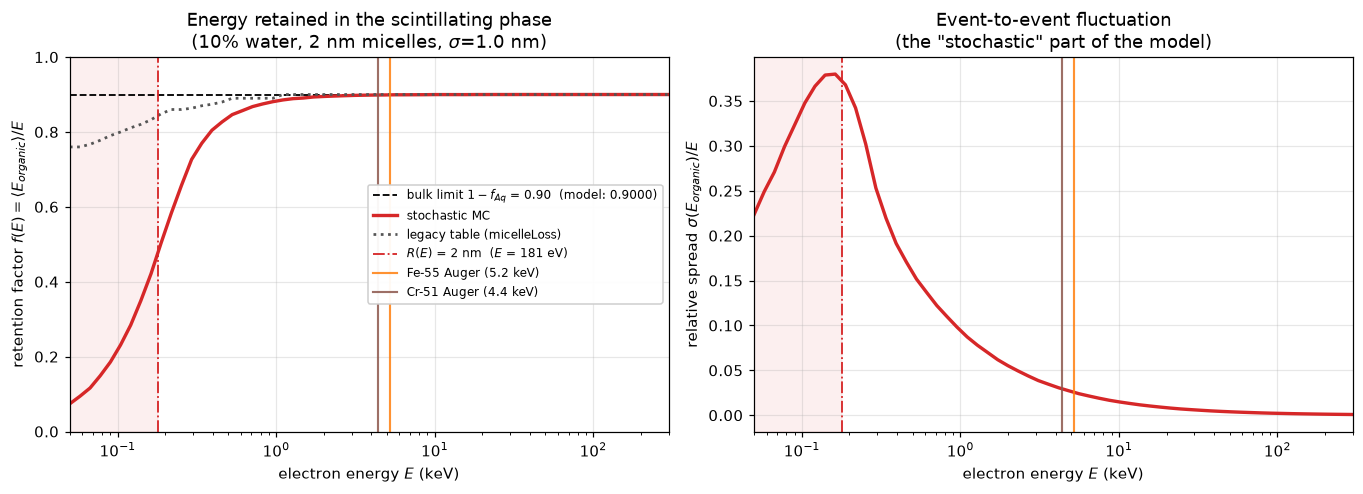

  E (keV)    R(E) (nm)     R/r_d      f(E)    table   sigma/E
     0.05          0.2      0.11    0.0749   0.7600    0.2238
     0.10          0.7      0.36    0.2150   0.8000    0.3398
     0.20          2.4      1.20    0.5329   0.8600    0.3592
     0.50         11.9      5.95    0.8397   0.8900    0.1590
     1.00         40.0     20.00    0.8822   0.9000    0.0946
     2.00        134.5     67.27    0.8948   0.9000    0.0555
     5.20        716.3    358.13    0.8992   0.9000    0.0257
     5.70        841.1    420.54    0.8991   0.9000    0.0237
    17.40       5929.5   2964.77    0.8999   0.9000    0.0095


    49.50      36950.4  18475.20    0.9000   0.9000    0.0039


    84.60      94397.0  47198.49    0.9000   0.9000    0.0025


In [4]:
mc = tl.pure_mc_efficient_energy_numba
NS = 40000                                   # samples per energy point
E_vec = np.logspace(np.log10(0.05), np.log10(300), 60)

f_hydro = np.empty_like(E_vec); s_hydro = np.empty_like(E_vec)
f_table = np.empty_like(E_vec)

t0 = time.time()
for i, E in enumerate(E_vec):
    m, s, _ = mc(E, r_d_nm=DIAM, sigma_r=SIGMA, f_w=FAQ, num_samples=NS)
    f_hydro[i], s_hydro[i] = m / E, s / E
    f_table[i] = tl.micelleLoss(E)           # legacy deterministic lookup
print(f'{len(E_vec)} energies x {NS} samples in {time.time()-t0:.1f} s')

# Plateau the model actually reaches at high energy. It sits slightly below
# 1-fAq; section 2.1 explains why.
f_plateau = float(np.mean(f_hydro[E_vec > 100]))

# Energy at which the electron range equals the micelle radius: R(E) = 40*E^1.75
E_conf = (DIAM / 40.0) ** (1 / 1.75)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ax.axvspan(E_vec[0], E_conf, color='#d62728', alpha=0.07)
ax.axhline(1 - FAQ, color='k', ls='--', lw=1.2,
           label=rf'bulk limit $1-f_{{Aq}}$ = {1-FAQ:.2f}'
                 f'  (model: {f_plateau:.4f})')
ax.plot(E_vec, f_hydro, '-', color='#d62728', lw=2.2, label='stochastic MC')
ax.plot(E_vec, f_table, ':', color='#555555', lw=1.8, label='legacy table (micelleLoss)')
ax.axvline(E_conf, color='#d62728', lw=1.2, ls='-.',
           label=f'$R(E)$ = {DIAM} nm  ($E$ = {E_conf*1e3:.0f} eV)')
# Markers only for the EC nuclides, whose signal sits at a well-defined Auger
# energy; a beta emitter's energy is distributed, so a line at its mean would
# mislead rather than inform.
for rad in EC_NUCLIDES:
    ax.axvline(INFO[rad][1], color=COLORS[rad], lw=1.4, alpha=0.85,
               label=f'{rad} Auger ({INFO[rad][1]:.1f} keV)')
ax.set_xscale('log'); ax.set_xlabel('electron energy $E$ (keV)')
ax.set_ylabel(r'retention factor $f(E)=\langle E_{organic}\rangle/E$')
ax.set_ylim(0, 1.0); ax.set_xlim(E_vec[0], E_vec[-1])
ax.set_title('Energy retained in the scintillating phase\n'
             f'({FAQ:.0%} water, {DIAM} nm micelles, $\\sigma$={SIGMA} nm)')
ax.legend(fontsize=8, loc='center right', framealpha=0.95); ax.grid(alpha=0.3)

ax = axes[1]
ax.axvspan(E_vec[0], E_conf, color='#d62728', alpha=0.07)
ax.plot(E_vec, s_hydro, '-', color='#d62728', lw=2.2)
ax.axvline(E_conf, color='#d62728', lw=1.2, ls='-.')
for rad in EC_NUCLIDES:
    ax.axvline(INFO[rad][1], color=COLORS[rad], lw=1.4, alpha=0.85)
ax.set_xscale('log'); ax.set_xlabel('electron energy $E$ (keV)')
ax.set_ylabel(r'relative spread $\sigma(E_{organic})/E$')
ax.set_xlim(E_vec[0], E_vec[-1])
ax.set_title('Event-to-event fluctuation\n(the "stochastic" part of the model)')
ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"E (keV)":>9s} {"R(E) (nm)":>12s} {"R/r_d":>9s} {"f(E)":>9s} '
      f'{"table":>8s} {"sigma/E":>9s}')
for E in [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.2, 5.7, 17.4, 49.5, 84.6]:
    m, s, _ = mc(E, r_d_nm=DIAM, sigma_r=SIGMA, f_w=FAQ, num_samples=NS)
    R = tl.calc_range_numba(E)
    print(f'{E:9.2f} {R:12.1f} {R/DIAM:9.2f} {m/E:9.4f} '
          f'{tl.micelleLoss(E):8.4f} {s/E:9.4f}')

**One tracer geometry, because only one occurs in practice.** An aqueous sample
enters an organic cocktail as reverse micelles, and the tracer goes with the
water — so the decay always starts inside a droplet. The mirror case, a
lipophilic tracer dissolved directly in the solvent, is not a configuration you
would ever set up alongside an aqueous fraction: with no water loaded there are
no micelles and nothing to correct. TDCRPy's quenching path reflects this, since
it calls the kernel with its `tracer_type='hydrophilic'` default and offers no
way to change it. Everything below is that single, physical case.

**Two regimes, separated by the electron range.**

* $E \gtrsim 3$ keV — the range ($\gtrsim 250$ nm, more than a hundred droplet
  radii) is far larger than a micelle. The track crosses many droplets and
  samples both phases in proportion to their volumes, so $f(E)$ saturates at the
  bulk limit $1-f_{Aq} = 0.90$: the correction degenerates into a flat 10 % cut
  in light yield, and where the track *started* no longer matters. This is what
  the legacy lookup assumes at every energy.
* $E \lesssim 3$ keV — the range becomes comparable to the droplet and the
  starting point dominates. The electron is *born inside water* and may never
  reach the solvent at all: $f$ falls below the bulk limit, and once the range
  drops under the micelle radius (shaded, left of the dash-dotted line) the
  electron is essentially trapped, with $f \to 0$. **This confinement penalty is
  the genuinely new physics the correction brings**, and it is precisely where
  the legacy table is blind.

The six nuclides of this study all have mean electron energies in the plateau,
so for their *bulk* behaviour the correction is close to a uniform $1-f_{Aq}$
rescaling. What separates them is how much of each spectrum reaches down into
the shaded region — which is why Fe-55, carried by Auger electrons of a few keV
and below, behaves differently from the β emitters in sections 3 and 4.

The right-hand panel shows the second novelty: the correction is not a
deterministic rescaling. It injects a per-decay dispersion of the retained
energy that peaks in the confinement regime, which broadens the photoelectron
distribution and therefore acts on the *triple-to-double ratio*, not only on the
mean light output.

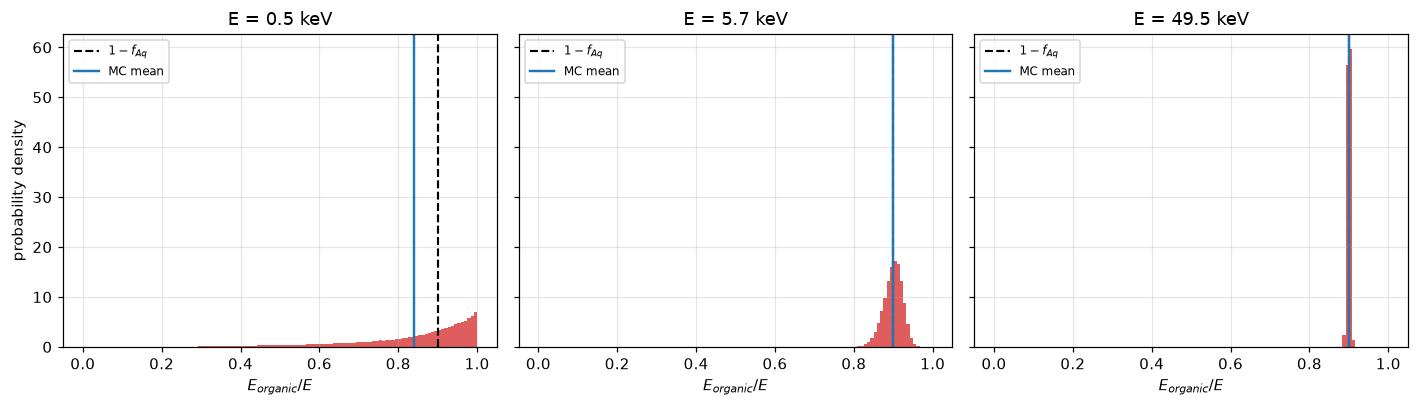

In [5]:
# Per-event distribution of the retained energy -- the deterministic table
# would be a single vertical line at 1 - fAq.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, E in zip(axes, [0.5, 5.7, 49.5]):
    _, _, samp = mc(E, r_d_nm=DIAM, sigma_r=SIGMA, f_w=FAQ, num_samples=200000)
    ax.hist(samp / E, bins=120, range=(0, 1), color='#d62728', alpha=0.75, density=True)
    ax.axvline(1 - FAQ, color='k', ls='--', lw=1.4, label=r'$1-f_{Aq}$')
    ax.axvline(np.mean(samp) / E, color='#1f77b4', lw=1.6, label='MC mean')
    ax.set_xlabel(r'$E_{organic}/E$'); ax.set_title(f'E = {E} keV')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axes[0].set_ylabel('probability density')
plt.tight_layout(); plt.savefig('micelle_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

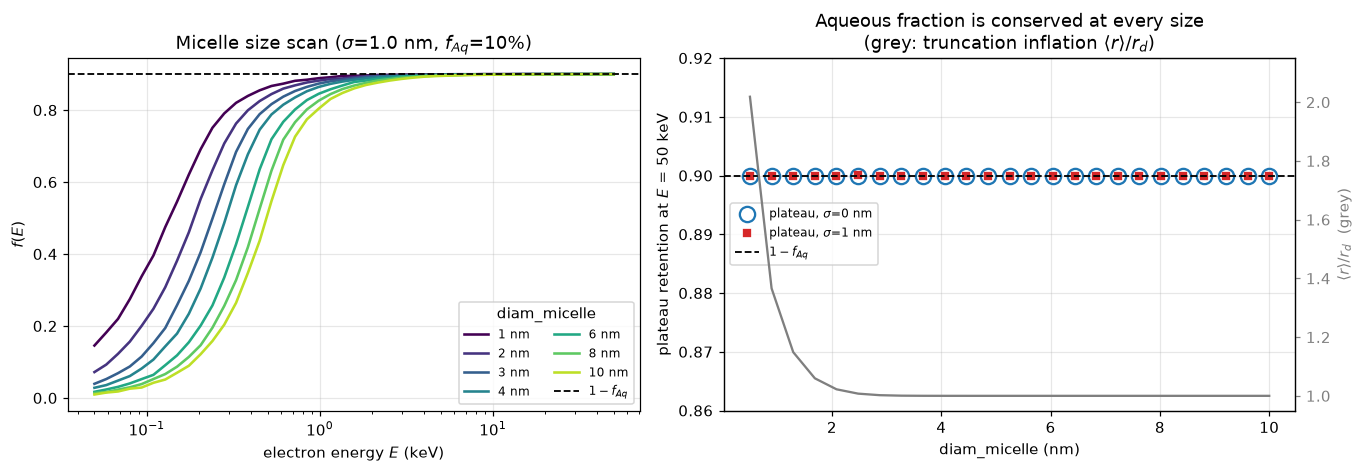

  r_d  sigma     <r>   <r>/r_d   plateau    1-fAq
--------------------------------------------------


    1    0.0  1.0000    1.0000    0.9000   0.9000


    1    1.0  1.2876    1.2876    0.9000   0.9000


    2    0.0  2.0000    1.0000    0.9000   0.9000


    2    1.0  2.0552    1.0276    0.9000   0.9000
    3    0.0  3.0000    1.0000    0.9000   0.9000


    3    1.0  3.0044    1.0015    0.9000   0.9000
    4    0.0  4.0000    1.0000    0.9000   0.9000


    4    1.0  4.0001    1.0000    0.9000   0.9000
    6    0.0  6.0000    1.0000    0.8999   0.9000
    6    1.0  6.0000    1.0000    0.9000   0.9000


    8    0.0  8.0000    1.0000    0.9000   0.9000
    8    1.0  8.0000    1.0000    0.8999   0.9000


In [6]:
# Left : retention vs energy for a range of micelle sizes.
# Right: why those curves do not all land on 1-fAq (see the markdown below).
from scipy.stats import norm

diam_vec = np.array([1, 2, 3, 4, 6, 8, 10])
E_sub = np.logspace(np.log10(0.05), np.log10(50), 45)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

cmap = plt.cm.viridis(np.linspace(0, 0.9, len(diam_vec)))
for c, d in zip(cmap, diam_vec):
    y = [mc(E, r_d_nm=d, sigma_r=SIGMA, f_w=FAQ, num_samples=20000)[0] / E
         for E in E_sub]
    axes[0].plot(E_sub, y, '-', color=c, lw=1.7, label=f'{d} nm')
axes[0].axhline(1 - FAQ, color='k', ls='--', lw=1.2, label=r'$1-f_{Aq}$')
axes[0].set_xscale('log'); axes[0].set_xlabel('electron energy $E$ (keV)')
axes[0].set_ylabel(r'$f(E)$')
axes[0].set_title(f'Micelle size scan ($\\sigma$={SIGMA} nm, $f_{{Aq}}$={FAQ:.0%})')
axes[0].legend(fontsize=8, title='diam_micelle', ncol=2, loc='lower right')
axes[0].grid(alpha=0.3)

# --- the plateau must now sit at 1-fAq for every size (v2.20.19) -----------
r_fine = np.linspace(0.5, 10, 25)
for s, col, mk, ms, fc in ((0.0, '#1f77b4', 'o', 10, 'none'),
                          (SIGMA, '#d62728', 's', 4, '#d62728')):
    meas = [mc(50.0, r_d_nm=r, sigma_r=s, f_w=FAQ, num_samples=40000)[0] / 50.0
            for r in r_fine]
    axes[1].plot(r_fine, meas, mk, color=col, ms=ms, ls='none', markerfacecolor=fc, markeredgewidth=1.5,
                 label=f'plateau, $\\sigma$={s:g} nm')
axes[1].axhline(1 - FAQ, color='k', ls='--', lw=1.2, label=r'$1-f_{Aq}$')

# the inflation factor that the fix corrects for, on a second axis
ax2 = axes[1].twinx()
ax2.plot(r_fine, [tl.mean_truncated_radius(r, SIGMA) / r for r in r_fine],
         '-', color='#7f7f7f', lw=1.5)
ax2.set_ylabel(r'$\langle r\rangle / r_d$  (grey)', color='#7f7f7f')
ax2.tick_params(axis='y', colors='#7f7f7f')
ax2.set_ylim(0.95, 2.15)

axes[1].set_xlabel('diam_micelle (nm)')
axes[1].set_ylabel('plateau retention at $E$ = 50 keV')
axes[1].set_ylim(0.86, 0.92)
axes[1].set_title('Aqueous fraction is conserved at every size\n'
                  r'(grey: truncation inflation $\langle r\rangle/r_d$)')
axes[1].legend(fontsize=8, loc='center left'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_scans.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"r_d":>5s} {"sigma":>6s} {"<r>":>7s} {"<r>/r_d":>9s} '
      f'{"plateau":>9s} {"1-fAq":>8s}')
print('-' * 50)
for r in (1, 2, 3, 4, 6, 8):
    for s in (0.0, SIGMA):
        Er = tl.mean_truncated_radius(float(r), s)
        meas = mc(50.0, r_d_nm=r, sigma_r=s, f_w=FAQ, num_samples=60000)[0] / 50.0
        print(f'{r:5d} {s:6.1f} {Er:7.4f} {Er/r:9.4f} {meas:9.4f} {1-FAQ:8.4f}')

### 2.1 Conserving the aqueous fraction: the sampled-radius correction

A subtlety worth spelling out, because it was wrong until TDCRPy **2.20.19**.
The micelle radius enters the kernel in two places, and they must be the same
radius:

* the **organic** mean free path,
  $\lambda = \tfrac{4}{3}\,\bar{r}\,(1-f_{Aq})/f_{Aq}$;
* each **aqueous** crossing, a chord of the sampled droplet
  $d = 2r\sqrt{u}$ with $r \sim \mathcal{N}(r_d, \sigma)$ **truncated at zero**
  (`get_micelle_radius` redraws while $r \le 0$), giving
  $\langle d \rangle = \tfrac{4}{3}\langle r \rangle$.

Truncation makes the radii actually drawn larger than the nominal value,

$$\langle r\rangle = r_d + \sigma\,\frac{\varphi(a)}{1-\Phi(a)},
  \qquad a = -\frac{r_d}{\sigma}$$

by a margin that matters only when $\sigma$ is comparable to $r_d$: at
$r_d = 1$ nm with $\sigma = 1$ nm, $\langle r\rangle = 1.288$ nm — 29 % high.

Until 2.20.19 the mean free path was built from the *nominal* $r_d$ while the
chords used the *sampled* radius. The aqueous path fraction was therefore
inflated by exactly $\langle r\rangle/r_d$, and the high-energy plateau fell
below the volume-fraction limit: **0.8748 instead of 0.9000** at $r_d = 1$ nm
(2.8 % too much quenching), 0.8975 at $r_d = 2$ nm — the config default — and
converging to 0.9000 only for $r_d \gtrsim 3$ nm. The model was quenching more
than the requested `fAq` asked for, and the error grew as the micelles got
smaller relative to their spread.

The fix (`mean_truncated_radius`) builds $\lambda$ from $\langle r\rangle$
instead, so the two radii agree and the aqueous path fraction collapses to
$f_{Aq}$ exactly:

$$f_\infty = 1 - \frac{\tfrac{4}{3}\langle r\rangle}
      {\tfrac{4}{3}\langle r\rangle\frac{1-f_{Aq}}{f_{Aq}}
       + \tfrac{4}{3}\langle r\rangle} = 1 - f_{Aq}$$

independent of $r_d$ and $\sigma$. The right-hand panel above confirms it: every
size now lands on $1-f_{Aq}$, for both $\sigma = 0$ and the default
$\sigma = 1$ nm. $\sigma$ still shapes the *spread* of the retained energy —
which is the physically meaningful role of a size distribution — but no longer
biases its mean.

## 3. TDCR-calibrated efficiencies — `eff()` optimisation at typical TD values

In a real measurement `L` is never imposed: it is *deduced* from the measured
triple-to-double ratio. `TDCRPy.eff(TD, ...)` does exactly that — it runs one MC
pass with `record=True`, bounded-scalar-minimises
$(T/D|_{\text{model}} - TD|_{\text{meas}})^2$ over `L`, then re-evaluates the
efficiencies at the optimum from the cached decay histories.

The micelle correction is applied to the *quenched* energies **before** they are
recorded, so it sits fully inside the loop: enabling it drives the optimiser to
a different `L`.

Because the TD set of section 1.1 describes a single counter, the fitted `L`
should now come out close to the same value for every nuclide in the
`micCorr = False` arm — a consistency check the previous, heterogeneous set
could not provide.

The TD values are the self-consistent set built in section 1.1 — three
measured, three inferred from the light yield of their anchor — so all six
describe the same counter.

### 3.1 The calibration curve, and why `Lbounds` has to be chosen with care

`eff()` minimises over `L` with `scipy.optimize.minimize_scalar(method='bounded')`
— a golden-section/parabolic search that assumes the residual is **unimodal**
inside the bracket. The curve below shows it is not: for Fe-55 the modelled
TDCR ratio *turns over* around $L \approx 20$ photons/keV and decreases again,
so the residual grows a second, spurious minimum against the upper bound. With
the `eff()` default `Lbounds=(0.1, 100)` the search walks into it and returns
`L ≈ 66` with a fitted TDCR of 0.95 instead of the requested 0.40 — **silently**,
since nothing in the return value flags a failed fit.

The curves are computed with the `record` → `readRecHist` trick: one MC pass per
case, then a pure replay at each `L`, which is what `objectFct` does internally.

The turnover is not a numerical artefact. Fe-55 emits Mn K X-rays that
frequently escape the counting volume, leaving a large population of very small
energy deposits. As `L` grows, those events are progressively recovered by the
*doubles* long before they can fire three PMTs, so `eff_D` climbs toward 1
faster than `eff_T` and their ratio falls. Any nuclide with a substantial
near-zero-deposit population will do the same.

H-3    calibration curves done


Fe-55  calibration curves done


Cr-51  calibration curves done


Ni-63  calibration curves done


C-14   calibration curves done


Tc-99  calibration curves done


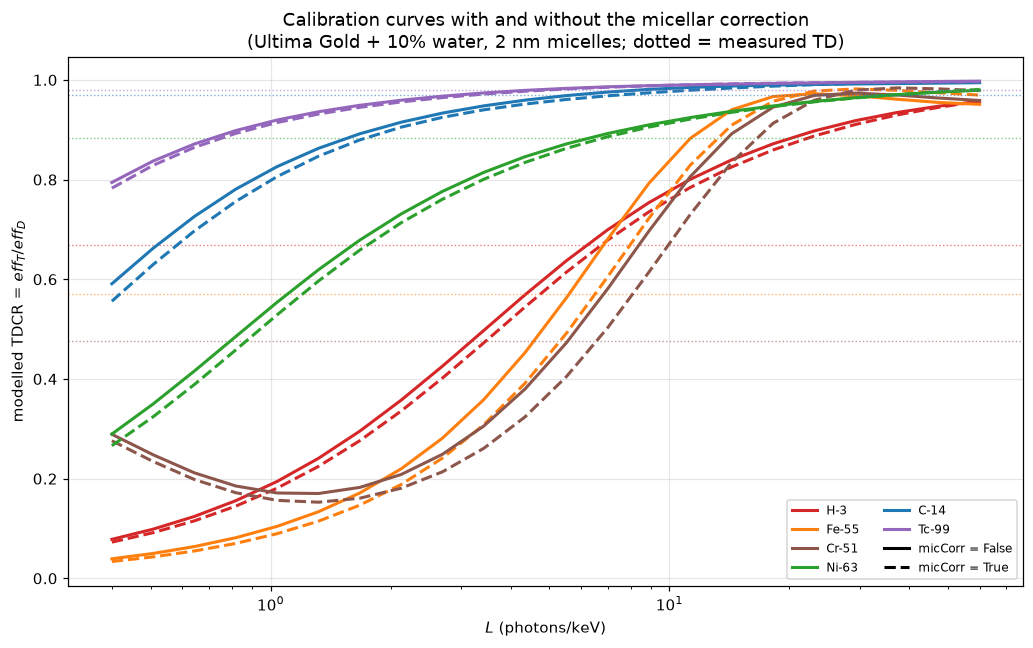

L at which the modelled TDCR peaks (micCorr=False):
  H-3      60.00 photons/keV  (max TDCR = 0.9570)
  Fe-55    23.10 photons/keV  (max TDCR = 0.9723)
  Cr-51    29.33 photons/keV  (max TDCR = 0.9735)
  Ni-63    60.00 photons/keV  (max TDCR = 0.9792)
  C-14     60.00 photons/keV  (max TDCR = 0.9944)
  Tc-99    60.00 photons/keV  (max TDCR = 0.9976)

vertical shift of the calibration curve at L = 8.0 photons/keV
nuclide   TDCR off   TDCR on   shift %
---------------------------------------
H-3         0.7281    0.7085     -2.69
Fe-55       0.7397    0.6671     -9.82
Cr-51       0.6420    0.5617    -12.51
Ni-63       0.9016    0.8962     -0.61
C-14        0.9785    0.9713     -0.74
Tc-99       0.9873    0.9868     -0.05


In [7]:
N_CAL = 3000                                   # lighter: this is a shape study
L_grid = np.logspace(np.log10(0.4), np.log10(60), 22)

calib = {}
for rad in NUCLIDES:
    for mic in (False, True):
        set_state(mic)
        tm.TDCRPy(2.0, rad, '1', N_CAL, KB, V, record=True)   # cache histories
        td = []
        for Lg in L_grid:
            o = tm.TDCRPy(Lg, rad, '1', N_CAL, KB, V, readRecHist=True)
            td.append(o[4] / o[2] if o[2] > 0 else np.nan)
        calib[(rad, mic)] = np.array(td)
    print(f'{rad:6s} calibration curves done', flush=True)

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9.5, 6))
for rad in NUCLIDES:
    ax.plot(L_grid, calib[(rad, False)], '-', color=COLORS[rad], lw=2.0)
    ax.plot(L_grid, calib[(rad, True)], '--', color=COLORS[rad], lw=2.0)
    ax.axhline(INFO[rad][0], color=COLORS[rad], ls=':', lw=0.9, alpha=0.6)
ax.set_xscale('log'); ax.set_xlabel('$L$ (photons/keV)')
ax.set_ylabel('modelled TDCR = $eff_T/eff_D$')
ax.set_title('Calibration curves with and without the micellar correction\n'
             f'({COCKTAIL} + {FAQ:.0%} water, {DIAM} nm micelles; '
             'dotted = measured TD)')
handles = [Line2D([], [], color=COLORS[r], lw=2, label=r) for r in NUCLIDES]
handles += [Line2D([], [], color='k', lw=2, ls='-', label='micCorr = False'),
            Line2D([], [], color='k', lw=2, ls='--', label='micCorr = True')]
ax.legend(handles=handles, fontsize=8, loc='lower right', ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('micelle_calibration_curve.png', dpi=150,
                                bbox_inches='tight')
plt.show()

imax = {rad: L_grid[int(np.nanargmax(calib[(rad, False)]))] for rad in NUCLIDES}
print('L at which the modelled TDCR peaks (micCorr=False):')
for rad in NUCLIDES:
    print(f'  {rad:6s} {imax[rad]:7.2f} photons/keV  '
          f'(max TDCR = {np.nanmax(calib[(rad, False)]):.4f})')

# How far the correction displaces the curve, read off at a reference L.
# This is the part of the effect that is NOT degenerate with L: a shift of the
# TDCR-vs-L relation cannot be undone by refitting L.
L_REF = 8.0
print(f'\nvertical shift of the calibration curve at L = {L_REF} photons/keV')
print(f'{"nuclide":8s} {"TDCR off":>9s} {"TDCR on":>9s} {"shift %":>9s}')
print('-' * 39)
for rad in NUCLIDES:
    t_off = float(np.interp(L_REF, L_grid, calib[(rad, False)]))
    t_on = float(np.interp(L_REF, L_grid, calib[(rad, True)]))
    print(f'{rad:8s} {t_off:9.4f} {t_on:9.4f} {relchange(t_off, t_on):9.2f}')

The bracket used below, `Lbounds = (0.5, 12)`, contains the physical solution
for all six nuclides in both arms while staying clear of the turnover. Every
fit is checked against its target afterwards, so a non-converged case cannot
pass unnoticed.

In [8]:
def run_effopt(rad, micCorr):
    set_state(micCorr)
    TD = INFO[rad][0]
    t0 = time.time()
    r = tm.eff(TD, rad, '1', KB, V, N=N_MC, L=2.0, maxiter=30, Lbounds=LBOUNDS)
    d = dict(L0=r[0], S=r[2], uS=r[3], D=r[4], uD=r[5], T=r[6], uT=r[7],
             TDCR=r[6] / r[4] if r[4] > 0 else np.nan, TD=TD,
             t=time.time() - t0)
    d['converged'] = abs(d['TDCR'] - TD) < 1e-3
    return d


resB = {}
for rad in NUCLIDES:
    resB[rad] = {}
    for mic in (False, True):
        resB[rad][mic] = run_effopt(rad, mic)
        r = resB[rad][mic]
        flag = 'ok' if r['converged'] else '*** FIT DID NOT CONVERGE ***'
        print(f'{rad:6s} micCorr={str(mic):5s}  TD_meas={r["TD"]:.3f}  '
              f'L0={r["L0"]:7.4f}  D={r["D"]:.5f}+-{r["uD"]:.5f}  '
              f'T={r["T"]:.5f}  TDCR_fit={r["TDCR"]:.5f}  {flag}   '
              f'[{r["t"]:.0f} s]', flush=True)

bad = [(rad, m) for rad in NUCLIDES for m in (False, True)
       if not resB[rad][m]['converged']]
print('\nAll fits converged.' if not bad else f'\nNON-CONVERGED: {bad}')

H-3    micCorr=False  TD_meas=0.669  L0= 6.1453  D=0.70246+-0.00108  T=0.46987  TDCR_fit=0.66890  ok   [222 s]


H-3    micCorr=True   TD_meas=0.669  L0= 6.7429  D=0.69566+-0.00110  T=0.46533  TDCR_fit=0.66890  ok   [329 s]


Fe-55  micCorr=False  TD_meas=0.570  L0= 5.5946  D=0.80013+-0.00086  T=0.45607  TDCR_fit=0.57000  ok   [2480 s]


Fe-55  micCorr=True   TD_meas=0.570  L0= 6.4997  D=0.79571+-0.00088  T=0.45355  TDCR_fit=0.57000  ok   [2820 s]


Cr-51  micCorr=False  TD_meas=0.477  L0= 5.6016  D=0.73814+-0.00076  T=0.35194  TDCR_fit=0.47680  ok   [1745 s]


...

C-14   micCorr=False  TD_meas=0.970  L0= 6.1166  D=0.96340+-0.00050  T=0.93450  TDCR_fit=0.97000  ok   [450 s]


C-14   micCorr=True   TD_meas=0.970  L0= 6.8419  D=0.96277+-0.00051  T=0.93389  TDCR_fit=0.97000  ok   [424 s]


Tc-99  micCorr=False  TD_meas=0.980  L0= 4.8532  D=0.97499+-0.00042  T=0.95549  TDCR_fit=0.98000  ok   [268 s]


Tc-99  micCorr=True   TD_meas=0.980  L0= 5.3768  D=0.97521+-0.00042  T=0.95570  TDCR_fit=0.98000  ok   [452 s]



All fits converged.



REGIME B -- L fitted to the measured TDCR, kB = 0.01 cm/MeV, Ultima Gold + 10% water, N = 100000

nuclide      TD    L off     L on  Delta_L %   eff_D off    eff_D on  Delta_D %  n_sigma
----------------------------------------------------------------------------------------
H-3        0.67   6.1453   6.7429       9.72     0.70246     0.69566      -0.97     -4.4
Fe-55      0.57   5.5946   6.4997      16.18     0.80013     0.79571      -0.55     -3.6
Cr-51      0.48   5.6016   6.5882      17.61     0.73814     0.73471      -0.46     -3.2
Ni-63      0.88   6.1545   6.7669       9.95     0.86351     0.86122      -0.27     -1.8
C-14       0.97   6.1166   6.8419      11.86     0.96340     0.96277      -0.07     -0.9
Tc-99      0.98   4.8532   5.3768      10.79     0.97499     0.97521       0.02      0.4


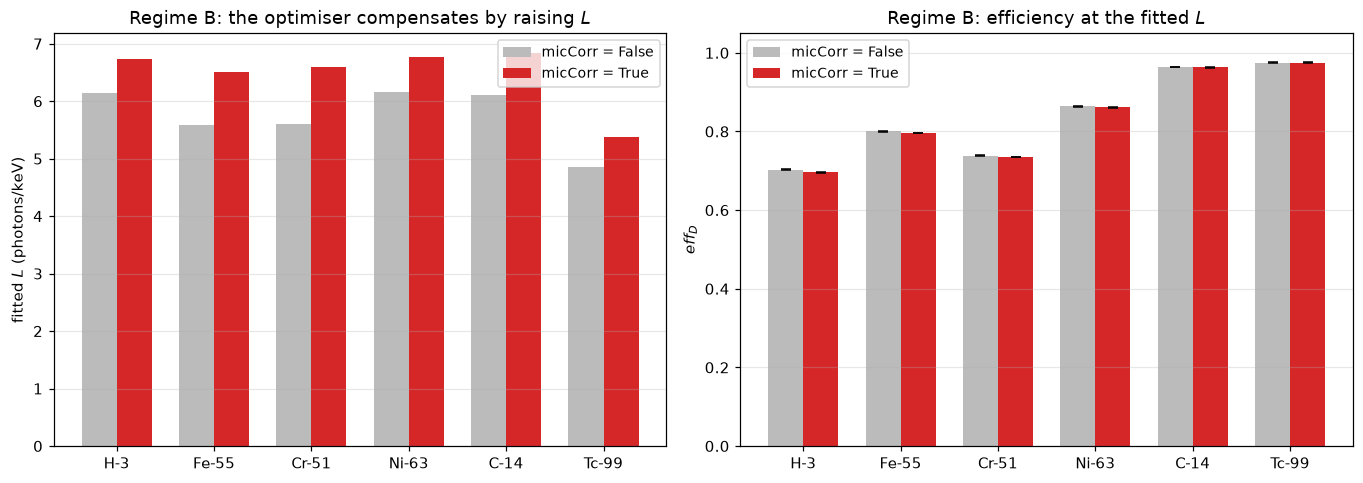

In [9]:
print(f'\nREGIME B -- L fitted to the measured TDCR, kB = 0.01 cm/MeV, '
      f'{COCKTAIL} + {FAQ:.0%} water, N = {N_MC}\n')
hdr = (f'{"nuclide":8s} {"TD":>6s} {"L off":>8s} {"L on":>8s} {"Delta_L %":>10s} '
       f'{"eff_D off":>11s} {"eff_D on":>11s} {"Delta_D %":>10s} {"n_sigma":>8s}')
print(hdr); print('-' * len(hdr))
tabB = {}
for rad in NUCLIDES:
    a, b = resB[rad][False], resB[rad][True]
    dL = relchange(a['L0'], b['L0']); dD = relchange(a['D'], b['D'])
    nsig = (b['D'] - a['D']) / np.hypot(a['uD'], b['uD'])
    tabB[rad] = (dL, dD, nsig)
    print(f'{rad:8s} {a["TD"]:6.2f} {a["L0"]:8.4f} {b["L0"]:8.4f} {dL:10.2f} '
          f'{a["D"]:11.5f} {b["D"]:11.5f} {dD:10.2f} {nsig:8.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
x = np.arange(len(NUCLIDES)); w = 0.36
axes[0].bar(x - w/2, [resB[r][False]['L0'] for r in NUCLIDES], w,
            color='#bbbbbb', label='micCorr = False')
axes[0].bar(x + w/2, [resB[r][True]['L0'] for r in NUCLIDES], w,
            color='#d62728', label='micCorr = True')
axes[0].set_xticks(x); axes[0].set_xticklabels(NUCLIDES)
axes[0].set_ylabel('fitted $L$ (photons/keV)')
axes[0].set_title('Regime B: the optimiser compensates by raising $L$')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, [resB[r][False]['D'] for r in NUCLIDES], w,
            yerr=[resB[r][False]['uD'] for r in NUCLIDES], capsize=3,
            color='#bbbbbb', label='micCorr = False')
axes[1].bar(x + w/2, [resB[r][True]['D'] for r in NUCLIDES], w,
            yerr=[resB[r][True]['uD'] for r in NUCLIDES], capsize=3,
            color='#d62728', label='micCorr = True')
axes[1].set_xticks(x); axes[1].set_xticklabels(NUCLIDES)
axes[1].set_ylabel('$eff_D$'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Regime B: efficiency at the fitted $L$')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.savefig('micelle_regimeB_efffit.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. What survives the calibration

The chart below is the headline result: the change in `eff_D` caused by
enabling `micCorr` **after** `L` has been re-fitted to the measured TDCR — the
way an activity measurement is actually made. Each bar carries its Monte-Carlo
uncertainty and, underneath, the significance of the shift. At N = 100 000 a
real effect of a few tenths of a percent is resolvable, so a bar consistent with
zero here is genuine evidence of cancellation rather than a limit of the
statistics.

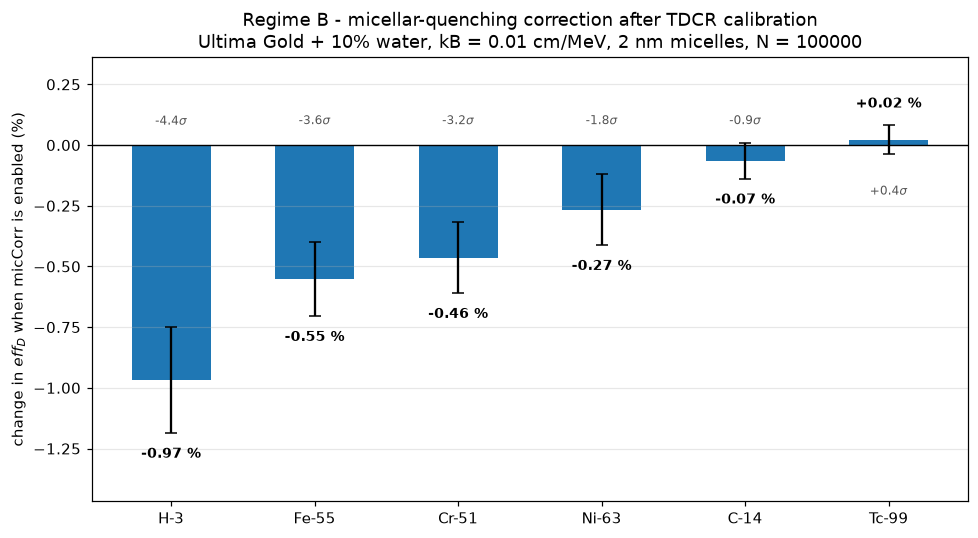

nuclide   <E_e> keV   TD meas |    L off     L on    d_L % |   d_effD %  n_sigma
----------------------------------------------------------------------------
H-3             5.7      0.67 |   6.1453   6.7429     9.72 |      -0.97     -4.4
Fe-55           5.2      0.57 |   5.5946   6.4997    16.18 |      -0.55     -3.6
Cr-51           4.4      0.48 |   5.6016   6.5882    17.61 |      -0.46     -3.2
Ni-63          17.4      0.88 |   6.1545   6.7669     9.95 |      -0.27     -1.8
C-14           49.5      0.97 |   6.1166   6.8419    11.86 |      -0.07     -0.9
Tc-99          84.6      0.98 |   4.8532   5.3768    10.79 |       0.02      0.4


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(NUCLIDES))
dB = [tabB[r][1] for r in NUCLIDES]
uB = [100 * np.hypot(resB[r][False]['uD'], resB[r][True]['uD']) / resB[r][False]['D']
      for r in NUCLIDES]
nsigB = [tabB[r][2] for r in NUCLIDES]

bars = ax.bar(x, dB, 0.55, yerr=uB, capsize=4, color='#1f77b4')
ax.axhline(0, color='k', lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(NUCLIDES)
ax.set_ylabel(r'change in $eff_D$ when micCorr is enabled (%)')
ax.set_title('Regime B - micellar-quenching correction after TDCR calibration\n'
             f'{COCKTAIL} + {FAQ:.0%} water, kB = 0.01 cm/MeV, '
             f'{DIAM} nm micelles, N = {N_MC}')
ax.grid(axis='y', alpha=0.3)

# annotate each bar with its value and its significance
span = max(abs(min(dB)), abs(max(dB))) or 1.0
for xi, (v, u, ns) in enumerate(zip(dB, uB, nsigB)):
    off = 0.06 * span * (-1 if v < 0 else 1)
    ax.text(xi, v + off + (u if v >= 0 else -u), f'{v:+.2f} %',
            ha='center', va='bottom' if v >= 0 else 'top',
            fontsize=9, fontweight='bold')
    ax.text(xi, -0.20 * span if v >= 0 else 0.10 * span, f'{ns:+.1f}$\\sigma$',
            ha='center', va='center', fontsize=8, color='#555555')
ax.margins(y=0.22)
plt.tight_layout(); plt.savefig('micelle_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"nuclide":8s} {"<E_e> keV":>10s} {"TD meas":>9s} | {"L off":>8s} '
      f'{"L on":>8s} {"d_L %":>8s} | {"d_effD %":>10s} {"n_sigma":>8s}')
print('-' * 76)
for rad in NUCLIDES:
    print(f'{rad:8s} {INFO[rad][1]:10.1f} {INFO[rad][0]:9.2f} | '
          f'{resB[rad][False]["L0"]:8.4f} {resB[rad][True]["L0"]:8.4f} '
          f'{tabB[rad][0]:8.2f} | {tabB[rad][1]:10.2f} {tabB[rad][2]:8.1f}')


## 5. Conclusions

**1. The TD set is self-consistent, and the fits confirm it.** In the
uncorrected arm the fitted light yields come out at 6.145 (H-3), 6.155 (Ni-63)
and 6.117 (C-14) — the three tied to the C-14 anchor — and 5.595 (Fe-55) and
5.602 (Cr-51) for the pair tied to Fe-55. Each group reproduces its anchor to
better than 1 %, which is the round-trip check: the inference of section 1.1
ran at N = 20 000 and these fits at N = 100 000, through `eff()`.

Tc-99 is the one genuinely independent input, and it lands at **4.853**. So the
three quoted measurements are only roughly mutually consistent: TD = 0.98 for
Tc-99 implies a light yield ~21 % lower than TD = 0.97 for C-14. Either the
counter was not the same, or one of the two ratios is off by a little — a
useful thing to be able to see.

**2. Under TDCR calibration the correction is again mostly absorbed into `L`,
but not entirely.** Enabling `micCorr` raises the fitted yield by **9.7 % to
17.6 %** and the recalculated `eff_D` then moves by **at most 1 %**:

| nuclide | `eff_D` | Δ`L` % | Δ`eff_D` % | significance |
|---|---|---|---|---|
| H-3 | 0.702 | +9.7 | **−0.97** | **−4.4σ** |
| Fe-55 | 0.800 | +16.2 | **−0.55** | **−3.6σ** |
| Cr-51 | 0.738 | +17.6 | **−0.46** | **−3.2σ** |
| Ni-63 | 0.864 | +10.0 | −0.27 | −1.8σ |
| C-14 | 0.963 | +11.9 | −0.07 | −0.9σ |
| Tc-99 | 0.975 | +10.8 | +0.02 | +0.4σ |

At N = 100 000 the first three are resolved beyond doubt. C-14 and Tc-99 are
consistent with exact cancellation.

**3. Two different things are going on, and they order the nuclides
differently.**

*The shape distortion* is carried by the **electron-capture** nuclides. Fe-55
and Cr-51 need a 16–18 % increase in `L` where every β emitter needs 10–12 %,
and their calibration curves are displaced far more at a common
`L` = 8 photons/keV:

| Cr-51 | Fe-55 | H-3 | C-14 | Ni-63 | Tc-99 |
|---|---|---|---|---|---|
| **−12.5 %** | **−9.8 %** | −2.7 % | −0.74 % | −0.61 % | −0.05 % |

Their signal is Auger electrons of a few keV — inside the confinement regime of
section 2 — and their X-rays frequently escape the vial, leaving a large
population of near-zero deposits exactly where the correction bites. A displaced
curve cannot be undone by refitting `L`.

*The residual efficiency bias*, by contrast, tracks **how far the nuclide is
from saturation**, not its decay mode. Ordered by `eff_D` — 0.702, 0.738,
0.800, 0.864, 0.963, 0.975 — the residual falls almost monotonically: −0.97,
−0.46, −0.55, −0.27, −0.07, +0.02 %. Where the efficiency curve is still steep,
the imperfect cancellation between a reduced photon budget and a raised `L`
shows up; where the nuclide has saturated, it cannot.

That is why **H-3 now carries the largest residual** (−0.97 %, 4.4σ) although
Cr-51 has both the lowest electron energy and the most distorted curve: at
`L` ≈ 6 photons/keV H-3 is the only nuclide still well down its efficiency
curve, at `eff_D` = 0.70. With the previous, lower-yield TD set (`L` ≈ 1.7–4.0)
the ranking was the other way round, with Cr-51 at −0.96 % and H-3 at −0.41 %.
**The residual is therefore a property of the working point, not of the nuclide
alone** — it has to be evaluated at the light yield you actually run at.

**Practical guidance.**

* For a well-performing counter (`L` ≈ 6 photons/keV, i.e. ~1.5 photoelectrons
  per keV per PMT) at a 10 % aqueous load, enabling `micCorr` changes the
  reported efficiency by **1 % or less** for every nuclide here — but that 1 %
  is real and resolved for H-3, Fe-55 and Cr-51, and should not be dismissed as
  noise.
* The fitted `L` is **not** interchangeable between the two settings: it absorbs
  the correction and shifts by 10–18 %, most for the EC nuclides. An `L`
  obtained with `micCorr = True` must not be reused with it off, nor
  transferred to a nuclide measured the other way.
* Check where your nuclide sits on its efficiency curve. Near saturation the
  correction cancels almost perfectly; on the steep part it does not.
* At **fixed `L`** none of this cancellation applies and the full several-percent
  effect is in play.
* Always pair `micCorr` with a correct `fAq`: the bulk composition effect (not
  studied here; see
  [`cocktailComposition.ipynb`](../advanced/cocktailComposition.ipynb)) is the
  larger of the two.

### Caveats on the current implementation

* **An inferred TD inherits the anchor's uncertainty, amplified.** Cr-51 sits on
  a steep part of its TDCR-vs-`L` curve, so the 3 % difference between the
  anchor `L` found at N = 20 000 here and a slightly different one moves its
  inferred TD by ~15 %. Inferred ratios are a way of building a coherent set,
  not a substitute for measuring the nuclide.
* **`eff()`'s default `Lbounds=(0.1, 100)` is not safe for every nuclide.** The
  modelled TDCR is not monotonic in `L` (section 3.1): it turns over near
  `L` ≈ 23 for Fe-55 and ≈ 29 for Cr-51, because their escaping X-rays leave
  many near-zero deposits that the *doubles* recover long before they can fire
  three PMTs, so `eff_D` climbs toward 1 faster than `eff_T`. The bounded
  search can settle into a spurious minimum against the upper bound and return
  an `L` reproducing the wrong TDCR, with no error and no warning. Bracket `L`
  and check `eff_T/eff_D` against the TD you asked for, as `run_effopt()` does.
* **The record/replay files were a fixed name in the shared system temp
  directory** up to and including 2.20.19 — the version this notebook was run
  with. Two TDCRPy processes on one machine overwrote each other's decay
  histories, and because `_run_from_history` silently skips the resulting
  malformed lines, the corruption biased results instead of raising. This run
  was therefore given its own `TEMP`, which isolates the record files.
  **Fixed in 2.20.20**: the names now carry the writing process's PID
  (`Temp_E2_<pid>.txt`, see `TDCR_model_lib.record_file_path`), so concurrent
  runs cannot collide; `cleanup_record_files()` removes them when you are done.
* `config.toml` lives inside the installed package and is **still** shared
  between concurrent processes, so two runs can overwrite each other's
  parameters. A private `TEMP` does not isolate it.
* The quenching path calls `pure_mc_efficient_energy_numba(eq)` with its
  defaults and reads `fAq`, `diam_micelle` and `sigma_micelle` as *keyword
  defaults bound at import time*, so changing them with `modify*()` requires an
  `importlib.reload` — which is what `set_state()` above does.
* The config key is named `diam_micelle` and documented as a diameter, but the
  kernel uses it as the **radius** of the sampled sphere. Read the values here
  as radii, or halve them if you mean diameters.
* Enabling `micCorr` costs roughly a factor 2–7 in runtime: the kernel is
  declared `@njit(parallel=True)` but the quenching path calls it with
  `num_samples=1`, so each call pays the thread-team setup for one `prange`
  iteration.
* `micelleLoss()` — the legacy deterministic GEANT4-DNA lookup — is still
  present but is no longer called by the quenching path.

In [11]:
# Restore the configuration exactly as it was before this notebook ran.
_quiet(tl.modifyLScocktail, NOMINAL['ls_cocktail'], NOMINAL['fAq'],
       NOMINAL['solvantType'], NOMINAL['solvantConc'])
tl.modifyDiam_micelle(NOMINAL['diam_micelle'])
tl.modifySigma_micelle(NOMINAL['sigma_micelle'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
print('config.toml restored:')
print(f'  ls_cocktail   = {NOMINAL["ls_cocktail"]}')
print(f'  fAq           = {tl.fAq}')
print(f'  micCorr       = {tl.micCorr}')
print(f'  diam_micelle  = {tl.diam_micelle}')
print(f'  sigma_micelle = {tl.sigma_micelle}')

config.toml restored:
  ls_cocktail   = Ultima Gold
  fAq           = 0.0
  micCorr       = False
  diam_micelle  = 2.0
  sigma_micelle = 1.0
